In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Ruta a la carpeta pr1 (ajusta si es necesario)
path_pr1 = "./pr1/" 

# Listamos los archivos para verificar
files = sorted(glob.glob(os.path.join(path_pr1, "*.nc")))
print(f"Se encontraron {len(files)} archivos en {path_pr1}")
for f in files:
    print(os.path.basename(f))

Se encontraron 8 archivos en ./pr1/
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19500101-19781231_chile.nc
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19790101-20141231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc


---

## 2. Unión de la Serie Histórica y Proyecciones
A diferencia de CR2MET, aquí tienes que decidir qué "futuro" quieres analizar (SSP370 o SSP585). Vamos a crear una función que cargue la serie completa (Histórica + Escenario).

In [3]:
def load_katerina_scenario(scenario_name="ssp585"):
    """
    Carga los archivos históricos y los concatena con el escenario elegido.
    """
    # Archivos históricos (1950-2014)
    hist_files = [f for f in files if "historical" in f]
    
    # Archivos del escenario (2015-2100)
    scen_files = [f for f in files if scenario_name in f]
    
    # Unimos las listas y cargamos con xarray
    all_files = hist_files + scen_files
    
    # Abrimos todos los archivos concatenándolos en la dimensión tiempo
    ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")
    
    # Aseguramos que las unidades de pr sean consistentes (suelen venir en kg/m2/s o mm/day)
    # Si es necesario, convertimos aquí.
    return ds_kat

# Cargamos el escenario SSP5-8.5 (el más extremo)
ds_kat = load_katerina_scenario("ssp585")
print("\nDataset cargado correctamente:")
print(ds_kat)


Dataset cargado correctamente:
<xarray.Dataset> Size: 65GB
Dimensions:      (time: 55152, y: 255, x: 68, nvertex: 4, axis_nbounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 441kB 1950-01-01T12:00:00 ... 2100-12-...
    lat          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
    lon          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_lat   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    bounds_lon   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    pr           (time, y, x) float32 4GB dask.array<chunksize=(1, 255, 68), meta=np.ndarray>
    time_bounds  (time, axis_nbounds) datetime64[ns] 882kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/30)
    description:                                      Created by xios
    Conven

C:\Users\elxpa\AppData\Local\Temp\ipykernel_29212\3689628994.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")


In [4]:
import numpy as np
import pandas as pd

# 1. Coordenadas de Santiago
lat_target, lon_target = -33.45, -70.66

# 2. Encontrar índices (y, x) más cercanos
# Calculamos la distancia usando las coordenadas 2D 'lat' y 'lon'
dist = np.sqrt((ds_kat.lat - lat_target)**2 + (ds_kat.lon - lon_target)**2)
indices = dist.argmin(dim=["y", "x"])

# 3. Extraer la serie y convertir a mm/día
# Seleccionamos por índice (isel) y cargamos en memoria (.compute)
stgo_series = ds_kat["pr"].isel(y=indices["y"], x=indices["x"]).compute()

# Crear DataFrame
df_kat = stgo_series.to_dataframe()[["pr"]]

# 4. Conversión de unidades (de kg/m2/s a mm/día)
# Multiplicamos por 86400 (segundos en un día)
df_kat["pr"] = df_kat["pr"] * 86400

# 5. Limpieza de "llovizna" (Drizzle effect)
# Aplicamos el umbral de 1mm para definir un día seco real
df_kat["pr"] = np.where(df_kat["pr"] < 1.0, 0, df_kat["pr"])

print("Serie de Santiago (Katerina) lista:")
print(df_kat.describe())

Serie de Santiago (Katerina) lista:
                 pr
count  55152.000000
mean       3.756280
std       10.799019
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      197.353561


---

## 2. Detección de Dry Spells y Tendencias (5-year Rolling)
Ahora aplicamos la misma lógica que usamos en CR2MET para ver la evolución histórica y futura.

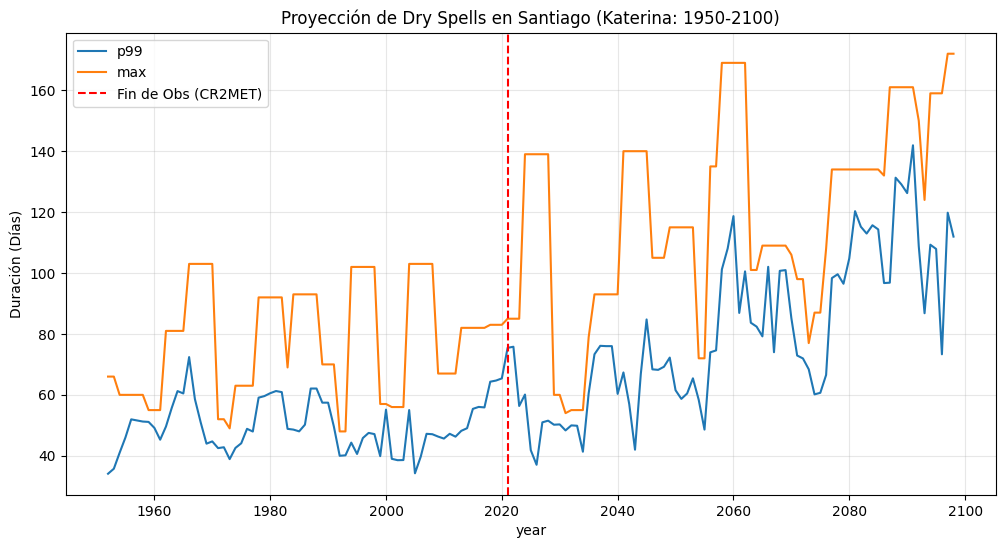

In [5]:
# Función para detectar rachas (la que ya teníamos)
def get_dry_spells(series):
    is_dry = series < 1.0
    tokens = is_dry.astype(int).diff().fillna(0)
    starts = np.where(tokens == 1)[0]
    ends = np.where(tokens == -1)[0]
    if is_dry.iloc[0]: starts = np.insert(starts, 0, 0)
    if is_dry.iloc[-1]: ends = np.append(ends, len(series)-1)
    durations = ends - starts
    return pd.DataFrame({"start": series.index[starts], "duration": durations})

# Calculamos las rachas
df_spells_kat = get_dry_spells(df_kat["pr"])
df_spells_kat["year"] = df_spells_kat["start"].dt.year

# Cálculo de métricas en ventanas móviles de 5 años (1950-2100)
results = []
years = np.arange(1950, 2097)

for y in years:
    mask = (df_spells_kat["year"] >= y) & (df_spells_kat["year"] <= y+4)
    data = df_spells_kat.loc[mask, "duration"]
    if not data.empty:
        results.append({
            "year": y + 2,
            "p99": np.percentile(data, 99),
            "max": data.max(),
            "mean": data.mean()
        })

df_trends_kat = pd.DataFrame(results).set_index("year")

# Graficar la tendencia de largo plazo
df_trends_kat[["p99", "max"]].plot(figsize=(12,6), title="Proyección de Dry Spells en Santiago (Katerina: 1950-2100)")
plt.axvline(x=2021, color='r', linestyle='--', label='Fin de Obs (CR2MET)')
plt.ylabel("Duración (Días)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<>:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\elxpa\AppData\Local\Temp\ipykernel_29212\1865166202.py:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"


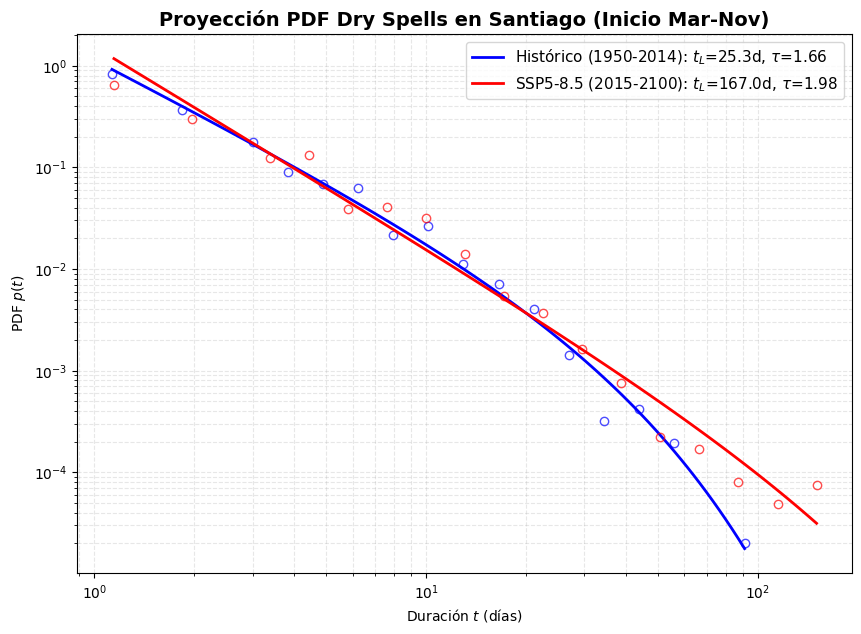

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Función para extraer y filtrar Dry Spells desde el DataFrame de Pandas
def extract_seasonal_spells_pd(df_precip, filter_type='start'):
    """
    df_precip: DataFrame con índice de fechas y columna 'pr' (mm/día)
    """
    is_dry = df_precip['pr'] < 1.0
    
    # Identificar inicios y términos
    x = np.r_[False, is_dry.values, False]
    dx = np.diff(x.astype(int))
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    
    durations = ends - starts
    valid = durations > 0
    starts = starts[valid]
    ends = ends[valid]
    durations = durations[valid]
    
    if len(durations) == 0:
        return np.array([])
        
    # Extraer meses usando el índice de fechas de Pandas
    fechas = df_precip.index
    start_months = fechas[starts].month
    end_months = fechas[ends - 1].month # ends-1 es el último día seco de la racha
    
    # Aplicar el filtro estacional (Marzo=3 a Noviembre=11)
    if filter_type == 'start':
        mask = (start_months >= 3) & (start_months <= 11)
    elif filter_type == 'end':
        mask = (end_months >= 3) & (end_months <= 11)
    else:
        mask = np.ones_like(durations, dtype=bool) # Sin filtro
        
    return durations[mask]

# 2. Separar la data en Histórica y Futura (SSP5-8.5)
df_hist = df_kat.loc['1950':'2014']
df_fut = df_kat.loc['2015':'2100']

# Extraer duraciones con FORMA 1 (Inicio en Mar-Nov)
# (Para revisar la Forma 2, simplemente cambia 'start' por 'end')
durs_hist = extract_seasonal_spells_pd(df_hist, filter_type='start')
durs_fut  = extract_seasonal_spells_pd(df_fut, filter_type='start')

# 3. Preparar el gráfico de PDF y Ajuste Log-Lineal
periodos = [
    {"data": durs_hist, "label": "Histórico (1950-2014)", "color": "blue"},
    {"data": durs_fut,  "label": "SSP5-8.5 (2015-2100)", "color": "red"}
]

plt.figure(figsize=(10, 7))

for p in periodos:
    data = p["data"]
    if len(data) < 3:
        continue # Prevenir errores si no hay datos suficientes
        
    # Binning logarítmico
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    
    valid_bins = counts > 0
    x_val = bin_centers[valid_bins]
    y_val = counts[valid_bins]
    
    # Fit por Mínimos Cuadrados (Log-Lineal del paper)
    if len(x_val) >= 3:
        Y = np.log(y_val)
        X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
        c, _, _, _ = np.linalg.lstsq(X_matrix, Y, rcond=None)
        c1, c2, c3 = c
        
        tau = -c2
        tL = -1.0 / c3 if c3 < 0 else np.inf 
        A_fit = np.exp(c1)
        
        # Crear la curva teórica para el gráfico
        t_range = np.logspace(np.log10(min(x_val)), np.log10(max(x_val)), 100)
        fit_curve = A_fit * (t_range**(-tau)) * np.exp(-t_range/tL)
        
        # Graficar puntos (scatter) y línea de ajuste
        plt.loglog(x_val, y_val, 'o', color=p["color"], mfc='none', alpha=0.7)
        
        tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"
        plt.plot(t_range, fit_curve, color=p["color"], lw=2,
                 label=f"{p['label']}: $t_L$={tL_str}, $\\tau$={tau:.2f}")

# Estética final del gráfico
plt.title("Proyección PDF Dry Spells en Santiago (Inicio Mar-Nov)", fontsize=14, fontweight='bold')
plt.xlabel("Duración $t$ (días)")
plt.ylabel("PDF $p(t)$")
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

=== Análisis de Significancia Estadística (ALADIN: Santiago) ===
Test Mann-Whitney (P-value): 6.6748e-05
Test Kolmogorov-Smirnov (P-value): 1.2291e-03
Conclusión: La diferencia proyectada es ESTADÍSTICAMENTE SIGNIFICATIVA.


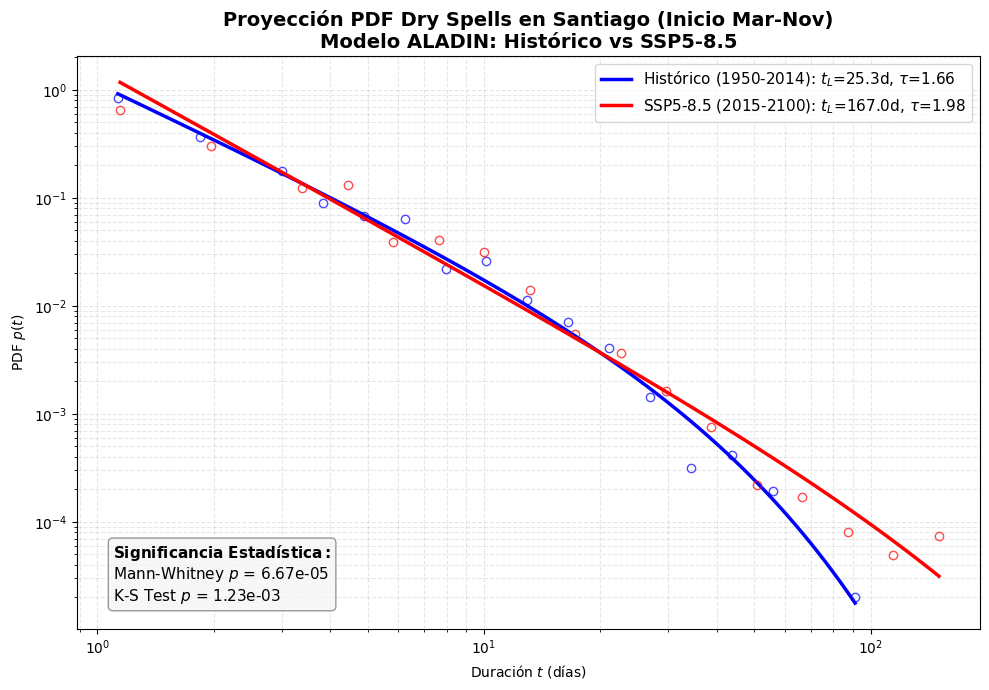

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Realizar los tests estadísticos
print("=== Análisis de Significancia Estadística (ALADIN: Santiago) ===")
mw_stat, mw_pval = stats.mannwhitneyu(durs_hist, durs_fut, alternative='two-sided')
ks_stat, ks_pval = stats.ks_2samp(durs_hist, durs_fut)

print(f"Test Mann-Whitney (P-value): {mw_pval:.4e}")
print(f"Test Kolmogorov-Smirnov (P-value): {ks_pval:.4e}")

if mw_pval < 0.05:
    print("Conclusión: La diferencia proyectada es ESTADÍSTICAMENTE SIGNIFICATIVA.")
else:
    print("Conclusión: NO hay diferencia estadísticamente significativa.")

# 2. Re-dibujar el gráfico incluyendo los resultados estadísticos
plt.figure(figsize=(10, 7))

for p in periodos:
    data = p["data"]
    if len(data) < 3:
        continue
        
    # Binning logarítmico
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    
    valid_bins = counts > 0
    x_val = bin_centers[valid_bins]
    y_val = counts[valid_bins]
    
    # Fit por Mínimos Cuadrados
    if len(x_val) >= 3:
        Y = np.log(y_val)
        X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
        c, _, _, _ = np.linalg.lstsq(X_matrix, Y, rcond=None)
        c1, c2, c3 = c
        
        tau = -c2
        tL = -1.0 / c3 if c3 < 0 else np.inf 
        A_fit = np.exp(c1)
        
        # Crear la curva teórica para el gráfico
        t_range = np.logspace(np.log10(min(x_val)), np.log10(max(x_val)), 100)
        fit_curve = A_fit * (t_range**(-tau)) * np.exp(-t_range/tL)
        
        # Graficar puntos y línea
        plt.loglog(x_val, y_val, 'o', color=p["color"], mfc='none', alpha=0.7)
        tL_str = f"{tL:.1f}d" if tL != np.inf else r"$\infty$"
        plt.plot(t_range, fit_curve, color=p["color"], lw=2.5,
                 label=f"{p['label']}: $t_L$={tL_str}, $\\tau$={tau:.2f}")

# Estética general
plt.title("Proyección PDF Dry Spells en Santiago (Inicio Mar-Nov)\nModelo ALADIN: Histórico vs SSP5-8.5", 
          fontsize=14, fontweight='bold')
plt.xlabel("Duración $t$ (días)")
plt.ylabel("PDF $p(t)$")
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.3)

# 3. AÑADIR CUADRO DE TEXTO CON LA SIGNIFICANCIA ESTADÍSTICA
textstr = '\n'.join((
    r'$\mathbf{Significancia\ Estadística:}$',
    f'Mann-Whitney $p$ = {mw_pval:.2e}',
    f'K-S Test $p$ = {ks_pval:.2e}'
))

# Propiedades de la cajita (fondo claro, bordes redondeados)
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8, edgecolor='gray')

# Colocar el texto en la esquina inferior izquierda (coordenadas relativas 0 al 1)
plt.gca().text(0.04, 0.04, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.show()